In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('comparison_results.csv')

# Classify circuit type from circuit name
def classify(name):
    if 'gausssum' in name: return 'Gaussian Sum'
    if 'treesum' in name: return 'Tree Sum'
    if 'seqsum' in name: return 'Sequential Sum'
    if 'bitonic' in name: return 'Bitonic Sort'
    if 'select' in name: return 'Selection'
    if 'treemech' in name: return 'Tree Mechanism'
    if 'distinct_hist' in name: return 'Distinct Elements (Histogram)'
    if 'distinct' in name: return 'Distinct Elements'
    if 'sort' in name: return 'Bitonic Sort'
    return 'Other'

df['circuit_type'] = df['circuit'].apply(classify)

# Filter to one bit_width per circuit type to avoid duplicate data points per N
preferred_bw = {
    'Sequential Sum': 8,
    'Tree Sum': 8,
    'Gaussian Sum': 8,
    'Selection': 8,
    'Bitonic Sort': 4,
    'Tree Mechanism': 8,
    'Distinct Elements': 4,
    'Distinct Elements (Histogram)': 4,
}
df = df[df.apply(lambda r: r['bit_width'] == preferred_bw.get(r['circuit_type'], r['bit_width']), axis=1)]

# For Selection, exp13 varies N (voters) and exp14 varies d (input length).
# Keep only exp13 for the N-based plots to avoid duplicate N=8 data points.
df = df[~((df['circuit_type'] == 'Selection') & (df['experiment'].str.startswith('exp14')))]

# For Tree Mechanism, exp15 varies N and exp16 varies T (steps).
# Keep only exp15 for the N-based plots to avoid duplicate N=8 data points.
df = df[~((df['circuit_type'] == 'Tree Mechanism') & (df['experiment'].str.startswith('exp16')))]

# All costs come from actual measured benchmark data in the CSV:
#   garble_time_us, ot_are_time_us, boundary_time_us  (microseconds)
#   garbled_table_bytes, ot_are_bytes, boundary_bytes  (bytes)
df.head()

,experiment,n_clients,circuit,circuit_gates,bit_width,balanced,client_id,num_gates,num_and,num_inputs,...,num_boundary_out,garble_time_us,ot_are_time_us,boundary_time_us,total_time_us,garbled_table_bytes,ot_are_bytes,boundary_bytes,total_bytes,circuit_type
0,exp1_and_N2_bal,2,and-chain-20,20,1,1,0,10,10,11,...,1,5.125,162708.000,0.0,162713.000,320,337920,0,338240,Other
1,exp1_and_N2_bal,2,and-chain-20,20,1,1,1,10,10,10,...,0,13.583,147684.000,19112.1,166810.000,320,307200,30720,338240,Other
2,exp1_and_N2_unbal,2,and-chain-20,20,1,0,0,20,20,21,...,0,13.792,317946.000,0.0,317960.000,640,645120,0,645760,Other
3,exp1_and_N2_unbal,2,and-chain-20,20,1,0,1,0,0,0,...,0,0.000,0.041,0.0,0.041,0,0,0,0,Other
4,exp1_and_N4_bal,4,and-chain-20,20,1,1,0,5,5,6,...,1,6.458,95984.000,0.0,95990.500,160,184320,0,184480,Other


In [23]:
# Aggregate per experiment: worst-case balanced client vs unbalanced client 0
def compute_costs(group):
    n = group['n_clients'].iloc[0]
    circuit = group['circuit'].iloc[0]
    balanced = group['balanced'].iloc[0]
    gates = group['circuit_gates'].iloc[0]
    ct = group['circuit_type'].iloc[0]

    total_and = group['num_and'].sum()
    total_inputs = group['num_inputs'].sum()
    total_boundary = group['num_boundary_in'].sum()

    avg_comp_ms = group['total_time_us'].mean() / 1000.0
    max_comp_ms = group['total_time_us'].max() / 1000.0
    avg_comm_KB = group['total_bytes'].mean() / 1024.0
    max_comm_KB = group['total_bytes'].max() / 1024.0

    return pd.Series({
        'n_clients': n, 'circuit': circuit, 'circuit_gates': gates,
        'balanced': balanced, 'circuit_type': ct,
        'total_and': total_and, 'total_inputs': total_inputs,
        'total_boundary': total_boundary,
        'avg_comp_ms': avg_comp_ms, 'max_comp_ms': max_comp_ms,
        'avg_comm_KB': avg_comm_KB, 'max_comm_KB': max_comm_KB,
    })

runs = df.groupby('experiment').apply(compute_costs).reset_index()

# Match balanced to unbalanced by circuit name + n_clients
unbal_base = runs[runs['balanced'] == 0].drop_duplicates(subset=['circuit', 'n_clients'], keep='first')
unbal_base = unbal_base.set_index(['circuit', 'n_clients'])[['max_comp_ms', 'max_comm_KB']]
unbal_base.columns = ['unbal_comp_ms', 'unbal_comm_KB']  # for unbalanced, avg=max=client0

bal_runs = runs[runs['balanced'] == 1].copy()
# Deduplicate balanced runs too (exp 11 and 13 may both have brick-8x4 balanced)
bal_runs = bal_runs.drop_duplicates(subset=['circuit', 'n_clients'], keep='first')
bal_runs = bal_runs.join(unbal_base, on=['circuit', 'n_clients'])
bal_runs['comp_speedup'] = bal_runs['unbal_comp_ms'] / bal_runs['avg_comp_ms']
bal_runs['comm_speedup'] = bal_runs['unbal_comm_KB'] / bal_runs['avg_comm_KB']

for ct in ['Sequential Sum', 'Tree Sum', 'Gaussian Sum', 'Selection', 'Bitonic Sort', 'Distinct Elements']:
    sub = bal_runs[bal_runs['circuit_type'] == ct].sort_values('n_clients')
    if len(sub) == 0: continue
    print(f'--- {ct} ---')
    for _, row in sub.iterrows():
        print(f"  N={int(row['n_clients']):3d}  {row['circuit']:>14s}  "
              f"balanced_avg={row['avg_comp_ms']:.1f}ms  "
              f"unbalanced={row['unbal_comp_ms']:.1f}ms  "
              f"speedup={row['comp_speedup']:.2f}x  |  "
              f"bal_comm_avg={row['avg_comm_KB']:.1f}KB  "
              f"unbal_comm={row['unbal_comm_KB']:.1f}KB  "
              f"savings={row['comm_speedup']:.2f}x")
    print()


--- Sequential Sum ---
  N=  2      seqsum-2x8  balanced_avg=208.2ms  unbalanced=242.7ms  speedup=1.17x  |  bal_comm_avg=420.2KB  unbal_comm=480.5KB  savings=1.14x
  N=  4      seqsum-4x8  balanced_avg=245.3ms  unbalanced=477.4ms  speedup=1.95x  |  bal_comm_avg=487.9KB  unbal_comm=961.5KB  savings=1.97x
  N=  8      seqsum-8x8  balanced_avg=293.2ms  unbalanced=951.4ms  speedup=3.25x  |  bal_comm_avg=574.2KB  unbal_comm=1923.9KB  savings=3.35x
  N= 10     seqsum-10x8  balanced_avg=305.8ms  unbalanced=1191.8ms  speedup=3.90x  |  bal_comm_avg=615.5KB  unbal_comm=2405.3KB  savings=3.91x
  N= 16     seqsum-16x8  balanced_avg=343.2ms  unbalanced=1897.4ms  speedup=5.53x  |  bal_comm_avg=692.5KB  unbal_comm=3850.3KB  savings=5.56x
  N= 32     seqsum-32x8  balanced_avg=465.5ms  unbalanced=3797.8ms  speedup=8.16x  |  bal_comm_avg=935.6KB  unbal_comm=7709.1KB  savings=8.24x

--- Tree Sum ---
  N=  2     treesum-2x8  balanced_avg=209.3ms  unbalanced=237.7ms  speedup=1.14x  |  bal_comm_avg=420.2KB 

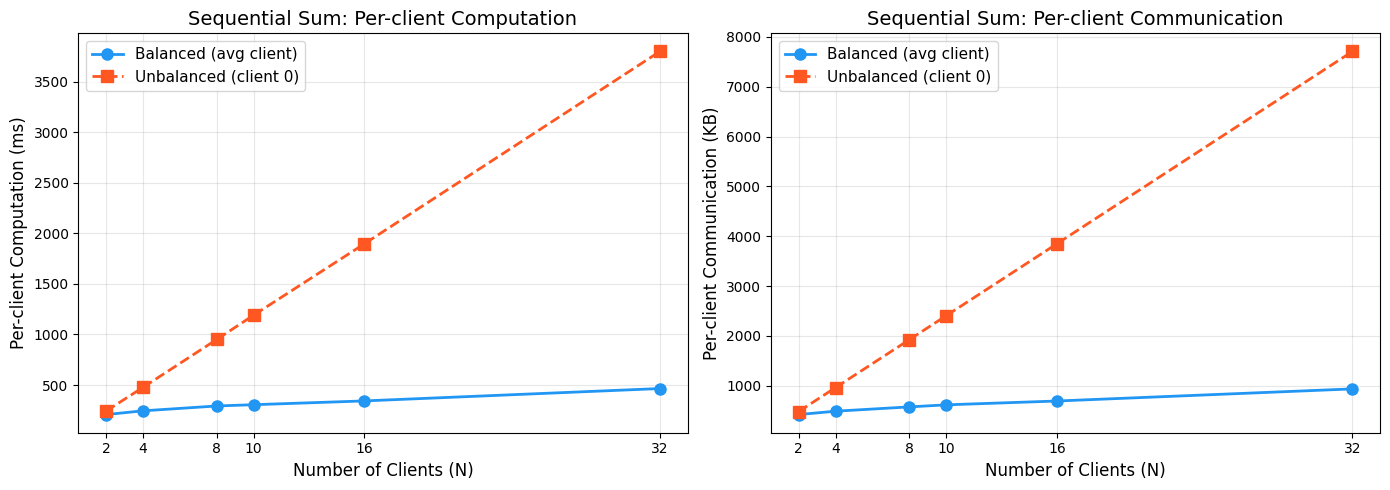

In [24]:
# ── Plot 1: Sequential Sum — Balanced vs Unbalanced ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sum_bal = bal_runs[bal_runs['circuit_type'] == 'Sequential Sum'].sort_values('n_clients')

if len(sum_bal) > 0:
    x = sum_bal['n_clients'].values
    axes[0].plot(x, sum_bal['avg_comp_ms'], 'o-', label='Balanced (avg client)', color='#2196F3', linewidth=2, markersize=8)
    axes[0].plot(x, sum_bal['unbal_comp_ms'], 's--', label='Unbalanced (client 0)', color='#FF5722', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('Sequential Sum: Per-client Computation', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, sum_bal['avg_comm_KB'], 'o-', label='Balanced (avg client)', color='#2196F3', linewidth=2, markersize=8)
    axes[1].plot(x, sum_bal['unbal_comm_KB'], 's--', label='Unbalanced (client 0)', color='#FF5722', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('Sequential Sum: Per-client Communication', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('plot_seqsum_balanced_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

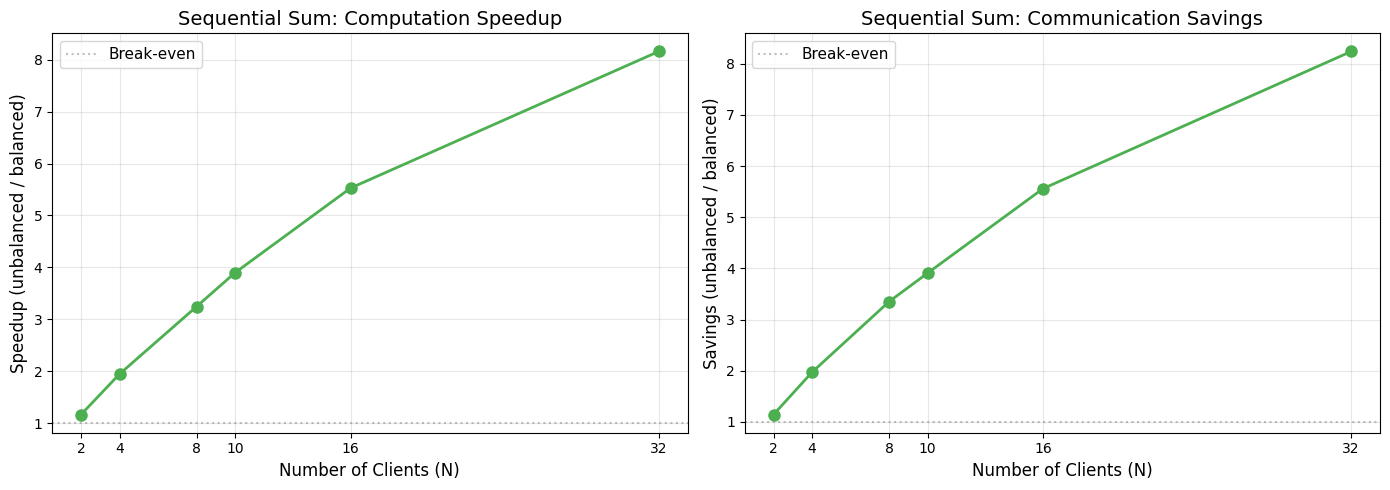

In [4]:
# ── Plot 2: Sequential Sum — Speedup vs N ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(sum_bal) > 0:
    x = sum_bal['n_clients'].values
    axes[0].plot(x, sum_bal['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[0].set_ylabel('Speedup (unbalanced / balanced)', fontsize=12)
    axes[0].set_title('Sequential Sum: Computation Speedup', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, sum_bal['comm_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[1].set_ylabel('Savings (unbalanced / balanced)', fontsize=12)
    axes[1].set_title('Sequential Sum: Communication Savings', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('plot_seqsum_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

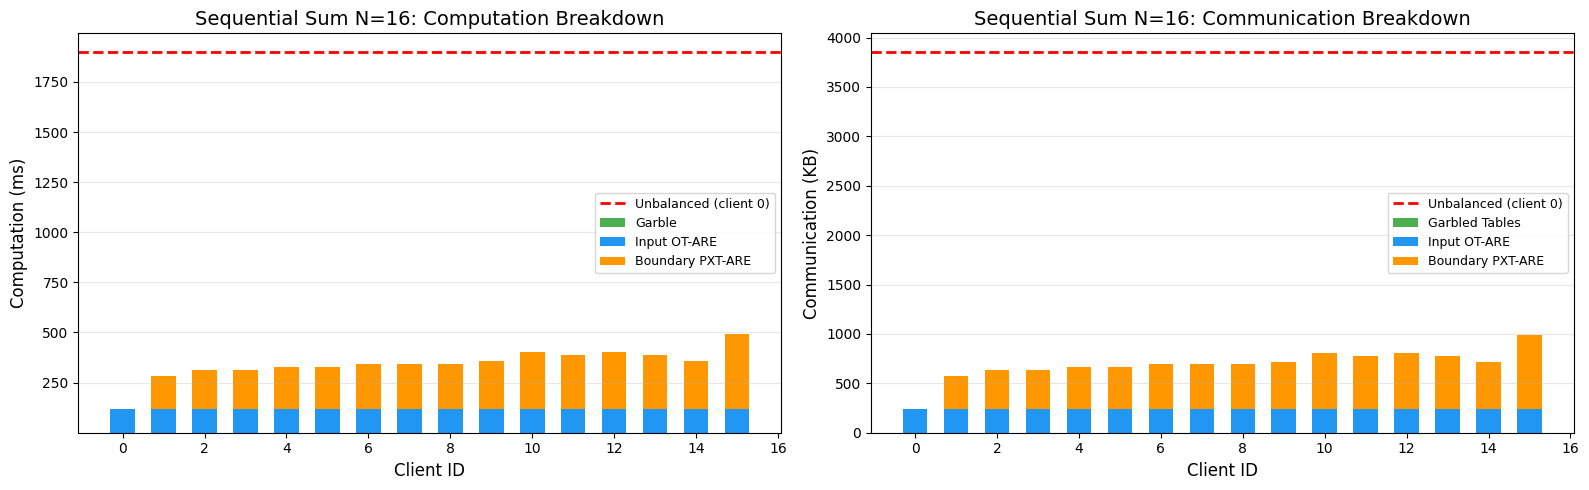

In [5]:
# ── Plot 3: Sequential Sum — Per-client breakdown (N=16) ─────────────────
exp_name = [e for e in df['experiment'].unique() if 'seqsum_N16_bal' in e]
if exp_name:
    breakdown = df[df['experiment'] == exp_name[0]].sort_values('client_id')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = breakdown['client_id']
    w = 0.6

    garble_t = breakdown['garble_time_us'].values / 1000.0
    input_t = breakdown['ot_are_time_us'].values / 1000.0
    boundary_t = breakdown['boundary_time_us'].values / 1000.0

    axes[0].bar(x, garble_t, w, label='Garble', color='#4CAF50')
    axes[0].bar(x, input_t, w, bottom=garble_t, label='Input OT-ARE', color='#2196F3')
    axes[0].bar(x, boundary_t, w, bottom=garble_t+input_t, label='Boundary PXT-ARE', color='#FF9800')
    # Unbalanced client 0 baseline
    unbal_exp = [e for e in df['experiment'].unique() if 'seqsum_N16_unbal' in e]
    if unbal_exp:
        unbal_c0 = df[(df['experiment'] == unbal_exp[0]) & (df['client_id'] == 0)]
        if len(unbal_c0):
            axes[0].axhline(y=unbal_c0['total_time_us'].values[0]/1000.0, color='red', linestyle='--', linewidth=2, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Client ID', fontsize=12)
    axes[0].set_ylabel('Computation (ms)', fontsize=12)
    axes[0].set_title('Sequential Sum N=16: Computation Breakdown', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    garble_c = breakdown['garbled_table_bytes'].values / 1024.0
    input_c = breakdown['ot_are_bytes'].values / 1024.0
    boundary_c = breakdown['boundary_bytes'].values / 1024.0

    axes[1].bar(x, garble_c, w, label='Garbled Tables', color='#4CAF50')
    axes[1].bar(x, input_c, w, bottom=garble_c, label='Input OT-ARE', color='#2196F3')
    axes[1].bar(x, boundary_c, w, bottom=garble_c+input_c, label='Boundary PXT-ARE', color='#FF9800')
    if unbal_exp:
        unbal_c0 = df[(df['experiment'] == unbal_exp[0]) & (df['client_id'] == 0)]
        if len(unbal_c0):
            axes[1].axhline(y=unbal_c0['total_bytes'].values[0]/1024.0, color='red', linestyle='--', linewidth=2, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Client ID', fontsize=12)
    axes[1].set_ylabel('Communication (KB)', fontsize=12)
    axes[1].set_title('Sequential Sum N=16: Communication Breakdown', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    #plt.savefig('plot_seqsum_breakdown_N16.png', dpi=150, bbox_inches='tight')
    plt.show()

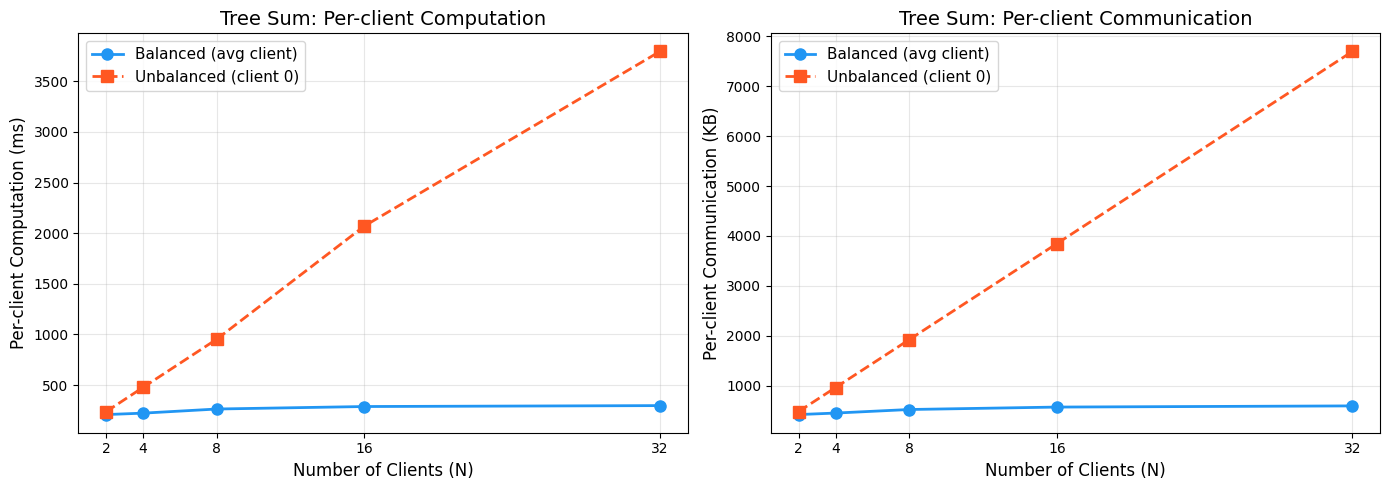

In [6]:
# ── Plot: Tree Sum — Balanced vs Unbalanced ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tree_bal = bal_runs[bal_runs['circuit_type'] == 'Tree Sum'].sort_values('n_clients')

if len(tree_bal) > 0:
    x = tree_bal['n_clients'].values
    axes[0].plot(x, tree_bal['avg_comp_ms'], 'o-', label='Balanced (avg client)', color='#2196F3', linewidth=2, markersize=8)
    axes[0].plot(x, tree_bal['unbal_comp_ms'], 's--', label='Unbalanced (client 0)', color='#FF5722', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('Tree Sum: Per-client Computation', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, tree_bal['avg_comm_KB'], 'o-', label='Balanced (avg client)', color='#2196F3', linewidth=2, markersize=8)
    axes[1].plot(x, tree_bal['unbal_comm_KB'], 's--', label='Unbalanced (client 0)', color='#FF5722', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('Tree Sum: Per-client Communication', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

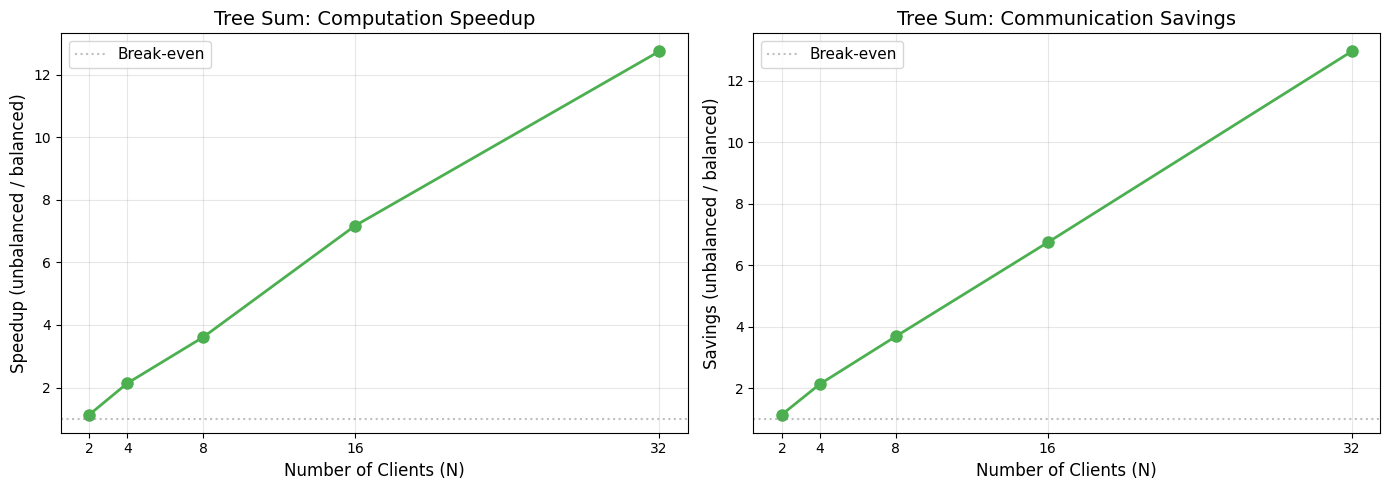

In [7]:
# ── Plot: Tree Sum — Speedup vs N ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(tree_bal) > 0:
    x = tree_bal['n_clients'].values
    axes[0].plot(x, tree_bal['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[0].set_ylabel('Speedup (unbalanced / balanced)', fontsize=12)
    axes[0].set_title('Tree Sum: Computation Speedup', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, tree_bal['comm_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Clients (N)', fontsize=12)
    axes[1].set_ylabel('Savings (unbalanced / balanced)', fontsize=12)
    axes[1].set_title('Tree Sum: Communication Savings', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

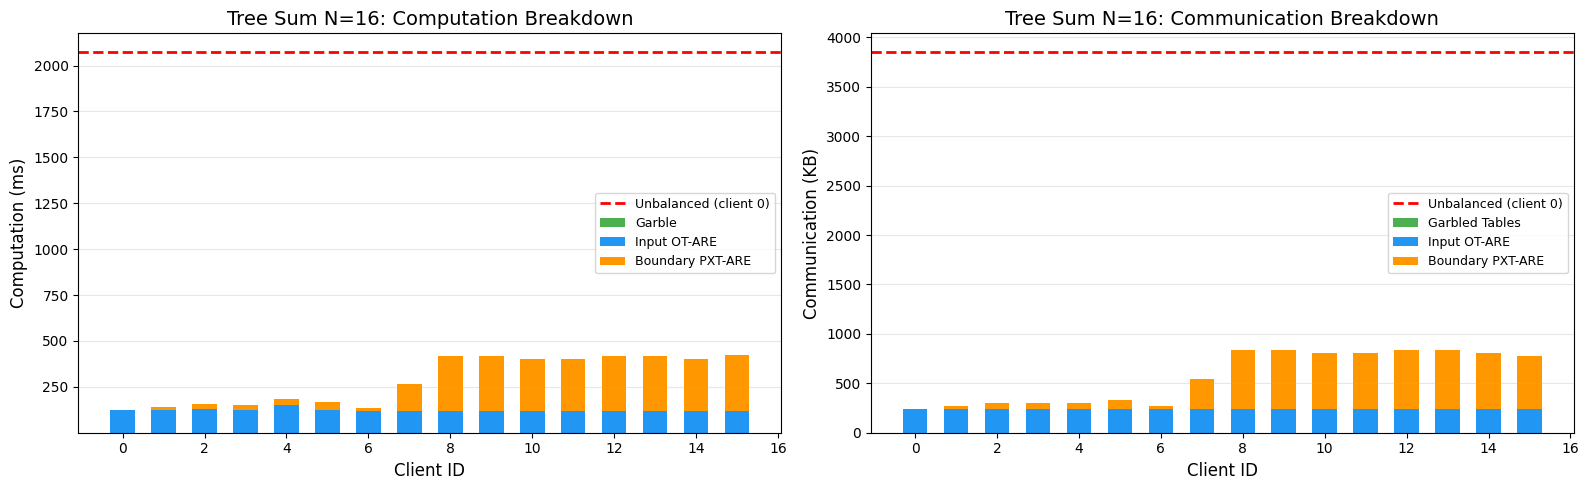

In [8]:
# ── Plot: Tree Sum — Per-client breakdown (N=16) ─────────────────────────
exp_name = [e for e in df['experiment'].unique() if 'treesum_N16_bal' in e]
if exp_name:
    breakdown = df[df['experiment'] == exp_name[0]].sort_values('client_id')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = breakdown['client_id']
    w = 0.6

    garble_t = breakdown['garble_time_us'].values / 1000.0
    input_t = breakdown['ot_are_time_us'].values / 1000.0
    boundary_t = breakdown['boundary_time_us'].values / 1000.0

    axes[0].bar(x, garble_t, w, label='Garble', color='#4CAF50')
    axes[0].bar(x, input_t, w, bottom=garble_t, label='Input OT-ARE', color='#2196F3')
    axes[0].bar(x, boundary_t, w, bottom=garble_t+input_t, label='Boundary PXT-ARE', color='#FF9800')
    unbal_exp = [e for e in df['experiment'].unique() if 'treesum_N16_unbal' in e]
    if unbal_exp:
        unbal_c0 = df[(df['experiment'] == unbal_exp[0]) & (df['client_id'] == 0)]
        if len(unbal_c0):
            axes[0].axhline(y=unbal_c0['total_time_us'].values[0]/1000.0, color='red', linestyle='--', linewidth=2, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Client ID', fontsize=12)
    axes[0].set_ylabel('Computation (ms)', fontsize=12)
    axes[0].set_title('Tree Sum N=16: Computation Breakdown', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    garble_c = breakdown['garbled_table_bytes'].values / 1024.0
    input_c = breakdown['ot_are_bytes'].values / 1024.0
    boundary_c = breakdown['boundary_bytes'].values / 1024.0

    axes[1].bar(x, garble_c, w, label='Garbled Tables', color='#4CAF50')
    axes[1].bar(x, input_c, w, bottom=garble_c, label='Input OT-ARE', color='#2196F3')
    axes[1].bar(x, boundary_c, w, bottom=garble_c+input_c, label='Boundary PXT-ARE', color='#FF9800')
    if unbal_exp:
        unbal_c0 = df[(df['experiment'] == unbal_exp[0]) & (df['client_id'] == 0)]
        if len(unbal_c0):
            axes[1].axhline(y=unbal_c0['total_bytes'].values[0]/1024.0, color='red', linestyle='--', linewidth=2, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Client ID', fontsize=12)
    axes[1].set_ylabel('Communication (KB)', fontsize=12)
    axes[1].set_title('Tree Sum N=16: Communication Breakdown', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

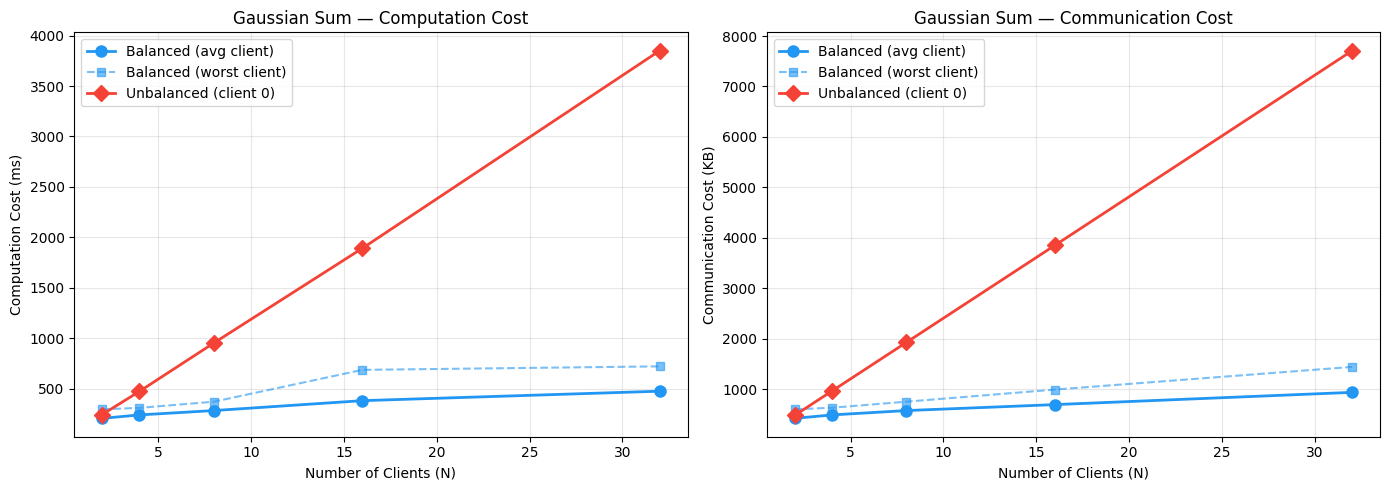

In [9]:
# ── Plot: Gaussian Sum — Balanced vs Unbalanced ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gauss_bal = bal_runs[bal_runs['circuit_type'] == 'Gaussian Sum'].sort_values('n_clients')

if len(gauss_bal) > 0:
    x = gauss_bal['n_clients'].values
    axes[0].plot(x, gauss_bal['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[0].plot(x, gauss_bal['max_comp_ms'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[0].plot(x, gauss_bal['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Number of Clients (N)')
    axes[0].set_ylabel('Computation Cost (ms)')
    axes[0].set_title('Gaussian Sum — Computation Cost')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, gauss_bal['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[1].plot(x, gauss_bal['max_comm_KB'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[1].plot(x, gauss_bal['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Number of Clients (N)')
    axes[1].set_ylabel('Communication Cost (KB)')
    axes[1].set_title('Gaussian Sum — Communication Cost')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

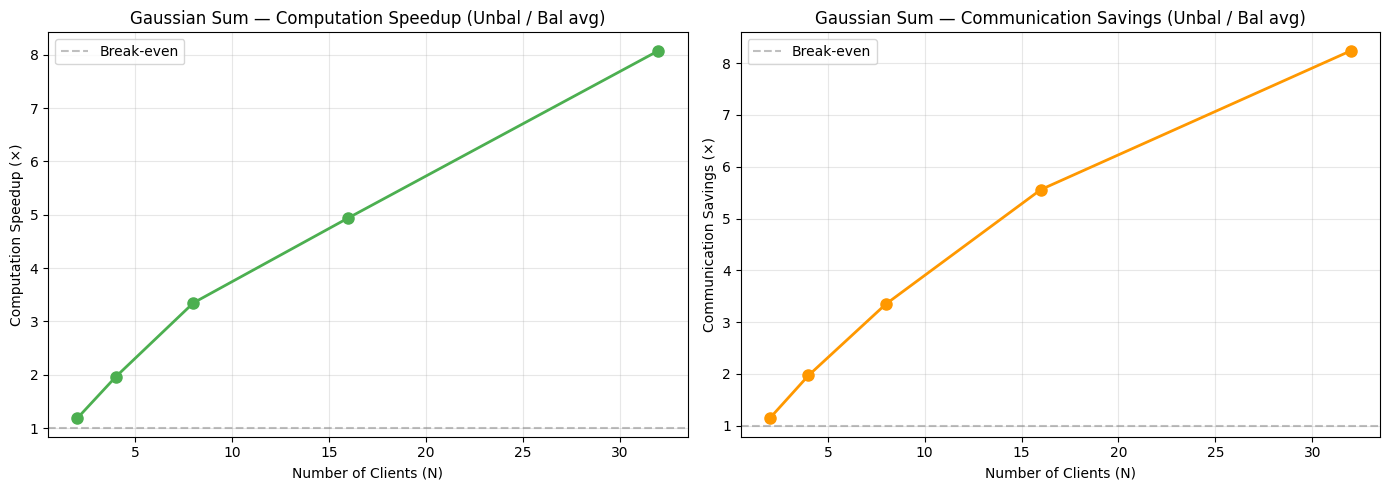

In [10]:
# ── Plot: Gaussian Sum — Speedup vs N ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(gauss_bal) > 0:
    x = gauss_bal['n_clients'].values
    axes[0].plot(x, gauss_bal['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Clients (N)')
    axes[0].set_ylabel('Computation Speedup (×)')
    axes[0].set_title('Gaussian Sum — Computation Speedup (Unbal / Bal avg)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, gauss_bal['comm_speedup'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Clients (N)')
    axes[1].set_ylabel('Communication Savings (×)')
    axes[1].set_title('Gaussian Sum — Communication Savings (Unbal / Bal avg)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

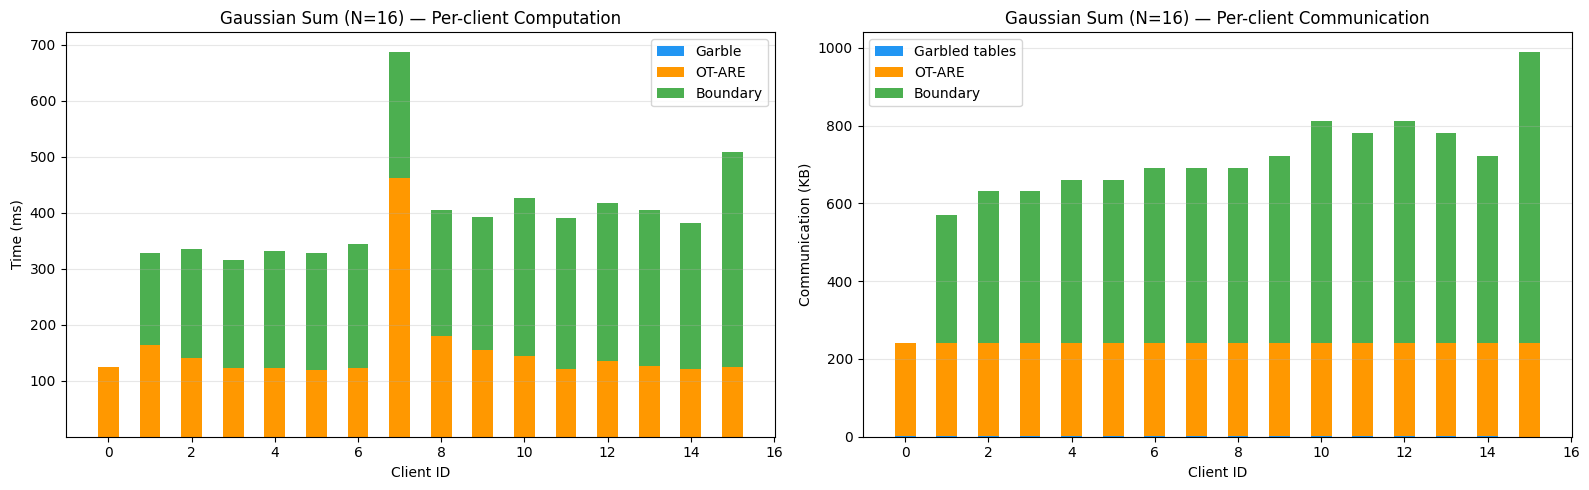

In [11]:
# ── Plot: Gaussian Sum — Per-client breakdown (N=16) ─────────────────────
exp_name = [e for e in df['experiment'].unique() if 'gausssum_N16_bal' in e]
if exp_name:
    breakdown = df[df['experiment'] == exp_name[0]].sort_values('client_id')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = breakdown['client_id'].values
    w = 0.5

    axes[0].bar(x, breakdown['garble_time_us']/1000, w, label='Garble', color='#2196F3')
    axes[0].bar(x, breakdown['ot_are_time_us']/1000, w, bottom=breakdown['garble_time_us']/1000, label='OT-ARE', color='#FF9800')
    axes[0].bar(x, breakdown['boundary_time_us']/1000, w, bottom=(breakdown['garble_time_us']+breakdown['ot_are_time_us'])/1000, label='Boundary', color='#4CAF50')
    axes[0].set_xlabel('Client ID')
    axes[0].set_ylabel('Time (ms)')
    axes[0].set_title('Gaussian Sum (N=16) — Per-client Computation')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].bar(x, breakdown['garbled_table_bytes']/1024, w, label='Garbled tables', color='#2196F3')
    axes[1].bar(x, breakdown['ot_are_bytes']/1024, w, bottom=breakdown['garbled_table_bytes']/1024, label='OT-ARE', color='#FF9800')
    axes[1].bar(x, breakdown['boundary_bytes']/1024, w, bottom=(breakdown['garbled_table_bytes']+breakdown['ot_are_bytes'])/1024, label='Boundary', color='#4CAF50')
    axes[1].set_xlabel('Client ID')
    axes[1].set_ylabel('Communication (KB)')
    axes[1].set_title('Gaussian Sum (N=16) — Per-client Communication')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

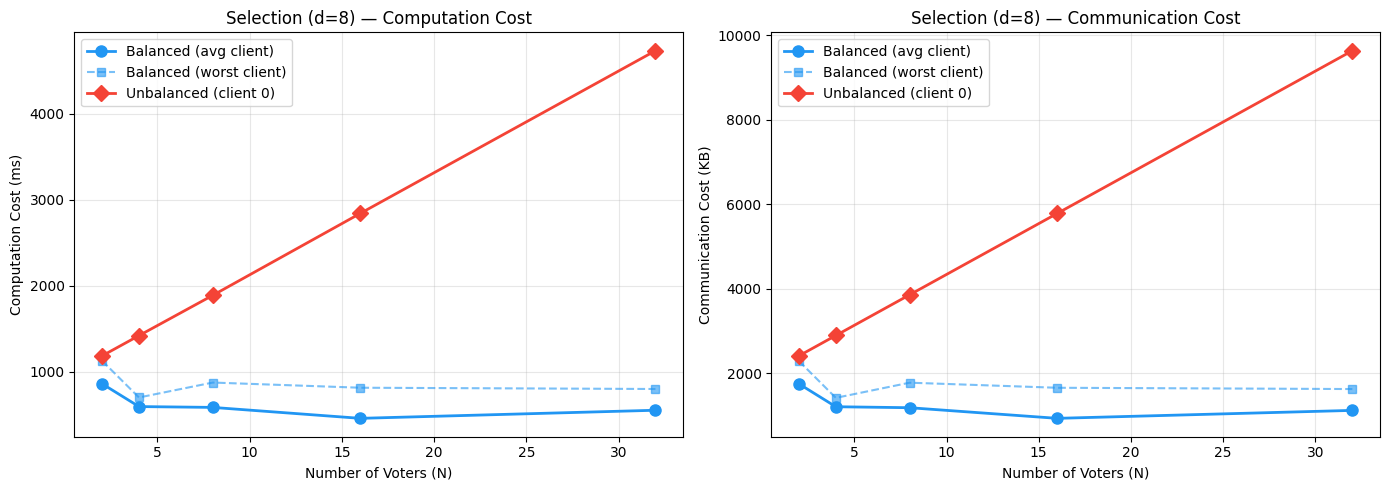

In [12]:
# ── Plot: Selection — Balanced vs Unbalanced ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sel_bal = bal_runs[bal_runs['circuit_type'] == 'Selection'].sort_values('n_clients')

if len(sel_bal) > 0:
    x = sel_bal['n_clients'].values
    axes[0].plot(x, sel_bal['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[0].plot(x, sel_bal['max_comp_ms'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[0].plot(x, sel_bal['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Number of Voters (N)')
    axes[0].set_ylabel('Computation Cost (ms)')
    axes[0].set_title('Selection (d=8) — Computation Cost')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, sel_bal['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[1].plot(x, sel_bal['max_comm_KB'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[1].plot(x, sel_bal['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Number of Voters (N)')
    axes[1].set_ylabel('Communication Cost (KB)')
    axes[1].set_title('Selection (d=8) — Communication Cost')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

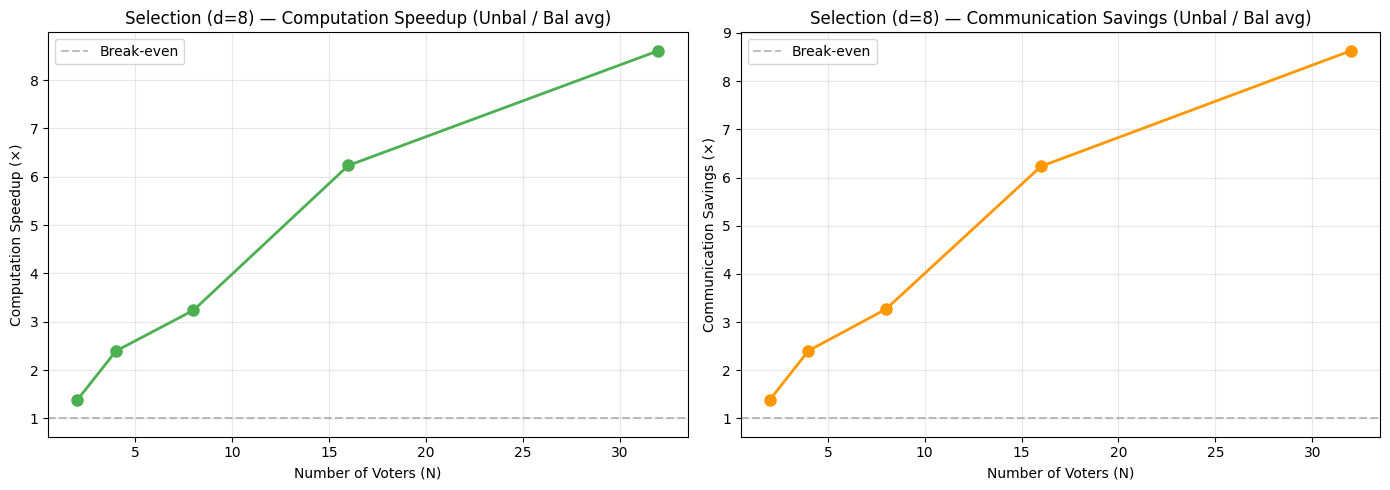

In [13]:
# ── Plot: Selection — Speedup vs N ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(sel_bal) > 0:
    x = sel_bal['n_clients'].values
    axes[0].plot(x, sel_bal['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Voters (N)')
    axes[0].set_ylabel('Computation Speedup (×)')
    axes[0].set_title('Selection (d=8) — Computation Speedup (Unbal / Bal avg)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, sel_bal['comm_speedup'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Voters (N)')
    axes[1].set_ylabel('Communication Savings (×)')
    axes[1].set_title('Selection (d=8) — Communication Savings (Unbal / Bal avg)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

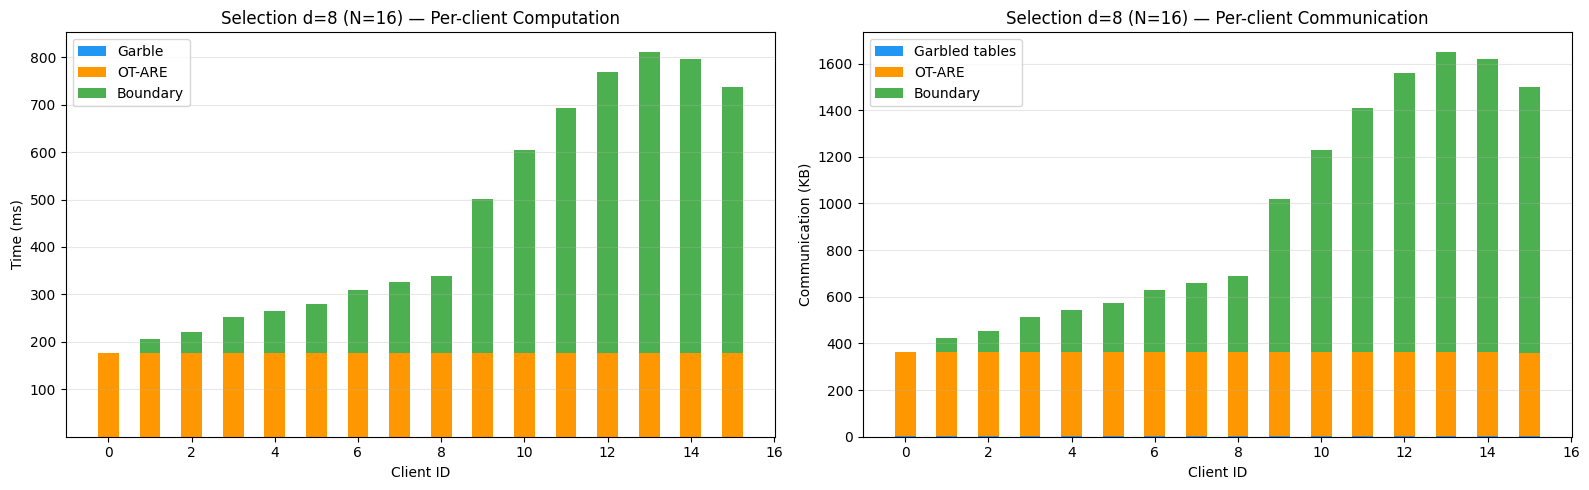

In [14]:
# ── Plot: Selection — Per-client breakdown (N=16) ────────────────────────
exp_name = [e for e in df['experiment'].unique() if 'select_N16_bal' in e]
if exp_name:
    breakdown = df[df['experiment'] == exp_name[0]].sort_values('client_id')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = breakdown['client_id'].values
    w = 0.5

    axes[0].bar(x, breakdown['garble_time_us']/1000, w, label='Garble', color='#2196F3')
    axes[0].bar(x, breakdown['ot_are_time_us']/1000, w, bottom=breakdown['garble_time_us']/1000, label='OT-ARE', color='#FF9800')
    axes[0].bar(x, breakdown['boundary_time_us']/1000, w, bottom=(breakdown['garble_time_us']+breakdown['ot_are_time_us'])/1000, label='Boundary', color='#4CAF50')
    axes[0].set_xlabel('Client ID')
    axes[0].set_ylabel('Time (ms)')
    axes[0].set_title('Selection d=8 (N=16) — Per-client Computation')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].bar(x, breakdown['garbled_table_bytes']/1024, w, label='Garbled tables', color='#2196F3')
    axes[1].bar(x, breakdown['ot_are_bytes']/1024, w, bottom=breakdown['garbled_table_bytes']/1024, label='OT-ARE', color='#FF9800')
    axes[1].bar(x, breakdown['boundary_bytes']/1024, w, bottom=(breakdown['garbled_table_bytes']+breakdown['ot_are_bytes'])/1024, label='Boundary', color='#4CAF50')
    axes[1].set_xlabel('Client ID')
    axes[1].set_ylabel('Communication (KB)')
    axes[1].set_title('Selection d=8 (N=16) — Per-client Communication')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

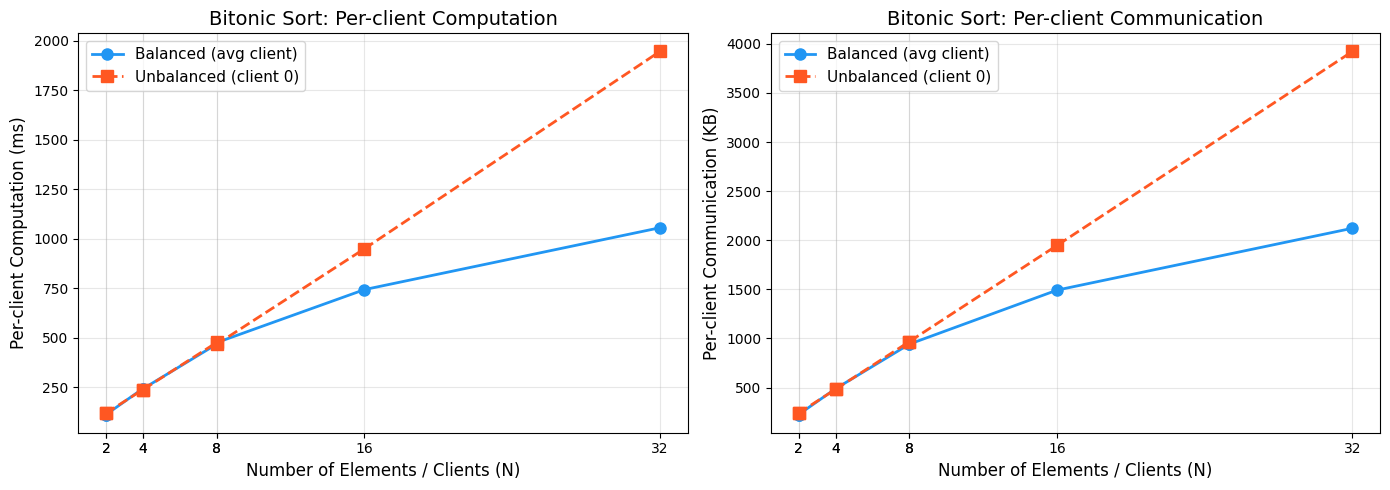

In [15]:
# ── Plot 4: Bitonic Sort — Balanced vs Unbalanced (extended N) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bitonic_bal = bal_runs[bal_runs['circuit_type'] == 'Bitonic Sort'].sort_values('n_clients')

if len(bitonic_bal) > 0:
    x = bitonic_bal['n_clients'].values
    axes[0].plot(x, bitonic_bal['avg_comp_ms'], 'o-', label='Balanced (avg client)', color='#2196F3', linewidth=2, markersize=8)
    axes[0].plot(x, bitonic_bal['unbal_comp_ms'], 's--', label='Unbalanced (client 0)', color='#FF5722', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Elements / Clients (N)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('Bitonic Sort: Per-client Computation', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, bitonic_bal['avg_comm_KB'], 'o-', label='Balanced (avg client)', color='#2196F3', linewidth=2, markersize=8)
    axes[1].plot(x, bitonic_bal['unbal_comm_KB'], 's--', label='Unbalanced (client 0)', color='#FF5722', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Elements / Clients (N)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('Bitonic Sort: Per-client Communication', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('plot_bitonic_balanced_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

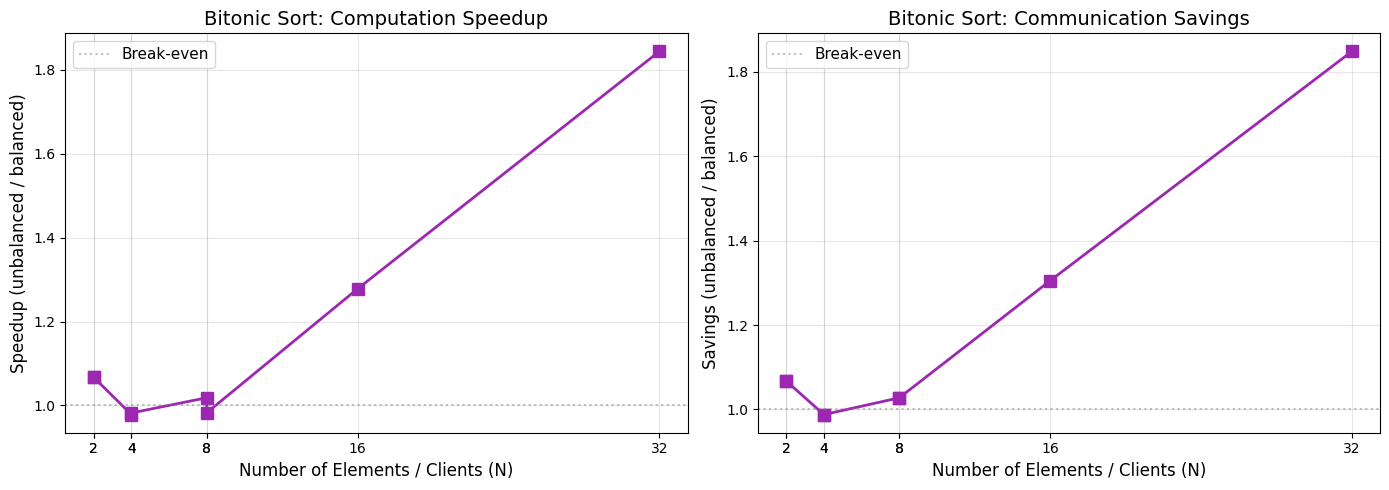

In [16]:
# ── Plot 5: Bitonic Sort — Speedup vs N ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(bitonic_bal) > 0:
    x = bitonic_bal['n_clients'].values
    axes[0].plot(x, bitonic_bal['comp_speedup'], 's-', color='#9C27B0', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Elements / Clients (N)', fontsize=12)
    axes[0].set_ylabel('Speedup (unbalanced / balanced)', fontsize=12)
    axes[0].set_title('Bitonic Sort: Computation Speedup', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, bitonic_bal['comm_speedup'], 's-', color='#9C27B0', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Elements / Clients (N)', fontsize=12)
    axes[1].set_ylabel('Savings (unbalanced / balanced)', fontsize=12)
    axes[1].set_title('Bitonic Sort: Communication Savings', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('plot_bitonic_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Summary tables ───────────────────────────────────────────────────────

cols = ['n_clients', 'circuit', 'circuit_gates', 'total_and', 'total_inputs',
        'total_boundary', 'avg_comp_ms', 'max_comp_ms', 'unbal_comp_ms', 'comp_speedup',
        'avg_comm_KB', 'max_comm_KB', 'unbal_comm_KB', 'comm_speedup']

for ct in ['Sequential Sum', 'Bitonic Sort', 'Brick Sort']:
    sub = bal_runs[bal_runs['circuit_type'] == ct].sort_values('n_clients')
    if len(sub) == 0:
        print(f'=== {ct} === (no data)')
        continue
    print(f'=== {ct} ===')
    display_cols = [c for c in cols if c in sub.columns]
    print(sub[display_cols].round(3).to_string(index=False))
    print()


=== Sequential Sum ===
 n_clients     circuit  circuit_gates  total_and  total_inputs  total_boundary  avg_comp_ms  max_comp_ms  unbal_comp_ms  comp_speedup  avg_comm_KB  max_comm_KB  unbal_comm_KB  comm_speedup
         2  seqsum-2x8             47         15            16              12      208.226      298.351        242.717         1.166      420.234      600.188        480.469         1.143
         4  seqsum-4x8            129         48            32              33      245.253      314.739        477.372         1.946      487.875      630.250        961.500         1.971
         8  seqsum-8x8            317        126            64              89      293.187      382.562        951.429         3.245      574.242      750.312       1923.938         3.350
        10 seqsum-10x8            423        171            80             125      305.760      420.502       1191.750         3.898      615.534      840.375       2405.344         3.908
        16 seqsum-16x8          

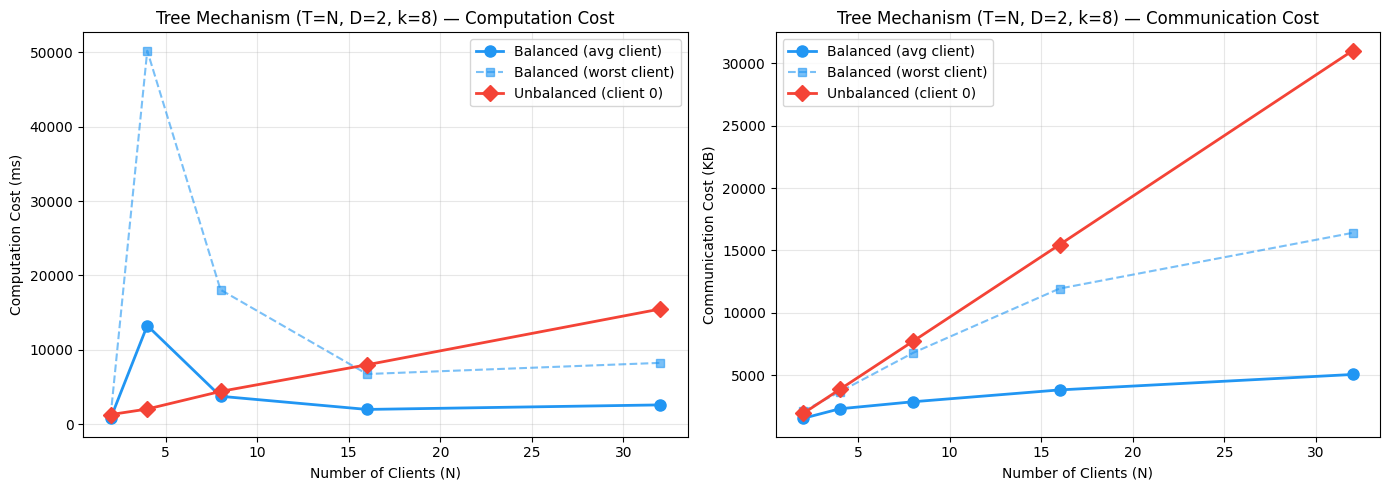

In [18]:
# ── Plot: Tree Mechanism — Balanced vs Unbalanced ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tm_bal = bal_runs[bal_runs["circuit_type"] == "Tree Mechanism"].sort_values("n_clients")

if len(tm_bal) > 0:
    x = tm_bal["n_clients"].values
    axes[0].plot(x, tm_bal["avg_comp_ms"], "o-", color="#2196F3", linewidth=2, markersize=8, label="Balanced (avg client)")
    axes[0].plot(x, tm_bal["max_comp_ms"], "s--", color="#2196F3", linewidth=1.5, markersize=6, alpha=0.6, label="Balanced (worst client)")
    axes[0].plot(x, tm_bal["unbal_comp_ms"], "D-", color="#F44336", linewidth=2, markersize=8, label="Unbalanced (client 0)")
    axes[0].set_xlabel("Number of Clients (N)")
    axes[0].set_ylabel("Computation Cost (ms)")
    axes[0].set_title("Tree Mechanism (T=N, D=2, k=8) — Computation Cost")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, tm_bal["avg_comm_KB"], "o-", color="#2196F3", linewidth=2, markersize=8, label="Balanced (avg client)")
    axes[1].plot(x, tm_bal["max_comm_KB"], "s--", color="#2196F3", linewidth=1.5, markersize=6, alpha=0.6, label="Balanced (worst client)")
    axes[1].plot(x, tm_bal["unbal_comm_KB"], "D-", color="#F44336", linewidth=2, markersize=8, label="Unbalanced (client 0)")
    axes[1].set_xlabel("Number of Clients (N)")
    axes[1].set_ylabel("Communication Cost (KB)")
    axes[1].set_title("Tree Mechanism (T=N, D=2, k=8) — Communication Cost")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

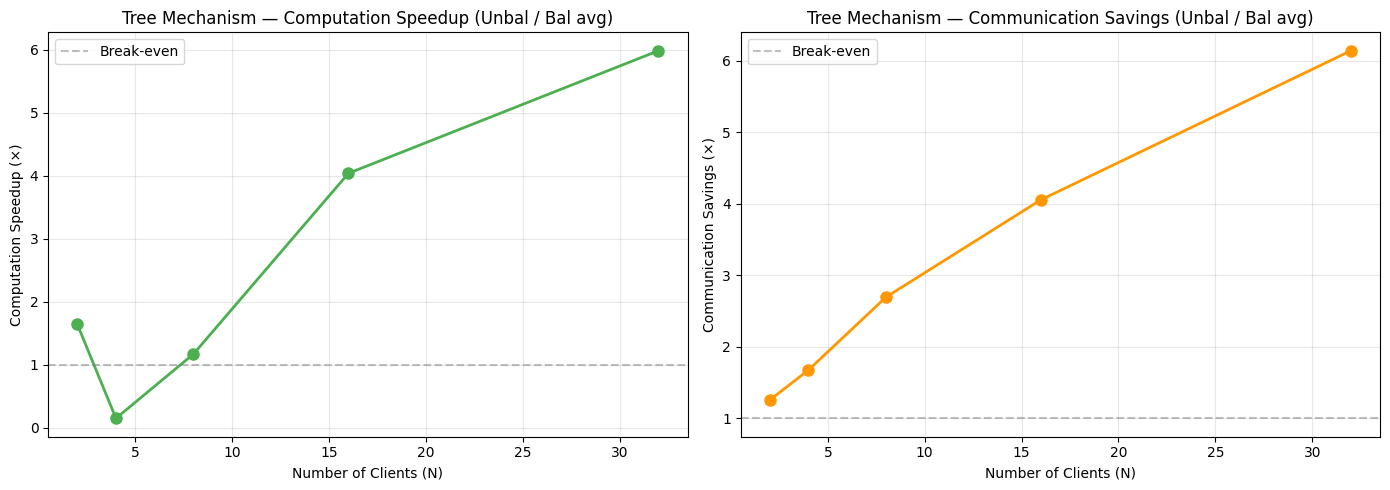

In [19]:
# ── Plot: Tree Mechanism — Speedup vs N ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(tm_bal) > 0:
    x = tm_bal["n_clients"].values
    axes[0].plot(x, tm_bal["comp_speedup"], "o-", color="#4CAF50", linewidth=2, markersize=8)
    axes[0].axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Break-even")
    axes[0].set_xlabel("Number of Clients (N)")
    axes[0].set_ylabel("Computation Speedup (×)")
    axes[0].set_title("Tree Mechanism — Computation Speedup (Unbal / Bal avg)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, tm_bal["comm_speedup"], "o-", color="#FF9800", linewidth=2, markersize=8)
    axes[1].axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Break-even")
    axes[1].set_xlabel("Number of Clients (N)")
    axes[1].set_ylabel("Communication Savings (×)")
    axes[1].set_title("Tree Mechanism — Communication Savings (Unbal / Bal avg)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Linear Contextual Bandits

The LCB circuit extends the Tree Mechanism to `D = d + d²` dimensions (d for the feature-reward vector u, d² for the Gram matrix V). We run three experiment sets:
- **Exp 17**: Vary N (T=N, d=2, D=6, k=8)
- **Exp 18**: Vary d (N=8, T=8, k=8)
- **Exp 19**: Vary T (N=4, d=2, D=6, k=8)

In [ ]:
# ── Load LCB benchmark results ───────────────────────────────────────────
import os

lcb_csv = 'lcb_all_results.csv'
if not os.path.exists(lcb_csv):
    # Fallback: are-protocol sibling of are-protocol-network
    lcb_csv = os.path.join('..', 'are-protocol', 'lcb_all_results.csv')

df_lcb = pd.read_csv(lcb_csv)
df_lcb['circuit_type'] = 'Linear Contextual Bandits'

print(f'Loaded {len(df_lcb)} LCB rows')
print(f'Experiments: {sorted(df_lcb["experiment"].unique())}')

runs_lcb = df_lcb.groupby('experiment').apply(compute_costs).reset_index()
runs_lcb['circuit_type'] = 'Linear Contextual Bandits'

unbal_lcb = runs_lcb[runs_lcb['balanced'] == 0].set_index(['circuit', 'n_clients'])[['max_comp_ms', 'max_comm_KB']]
unbal_lcb.columns = ['unbal_comp_ms', 'unbal_comm_KB']

bal_lcb = runs_lcb[runs_lcb['balanced'] == 1].copy()
bal_lcb = bal_lcb.join(unbal_lcb, on=['circuit', 'n_clients'])
bal_lcb['comp_speedup'] = bal_lcb['unbal_comp_ms'] / bal_lcb['avg_comp_ms']
bal_lcb['comm_speedup'] = bal_lcb['unbal_comm_KB'] / bal_lcb['avg_comm_KB']

for prefix, label in [('exp17', 'Exp 17: Vary N (T=N, d=2)'),
                       ('exp18', 'Exp 18: Vary d (N=8, T=8)'),
                       ('exp19', 'Exp 19: Vary T (N=4, d=2)')]:
    sub = bal_lcb[bal_lcb['experiment'].str.startswith(prefix)].sort_values('n_clients')
    if len(sub) == 0: continue
    print(f'\n--- {label} ---')
    for _, row in sub.iterrows():
        print(f"  {row['circuit']:>16s}  "
              f"balanced_avg={row['avg_comp_ms']:.1f}ms  "
              f"unbalanced={row['unbal_comp_ms']:.1f}ms  "
              f"speedup={row['comp_speedup']:.2f}x  |  "
              f"bal_comm={row['avg_comm_KB']:.1f}KB  "
              f"unbal_comm={row['unbal_comm_KB']:.1f}KB  "
              f"savings={row['comm_speedup']:.2f}x")

In [ ]:
# ── LCB Plot 1: Balanced vs Unbalanced — Vary N (T=N, d=2) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lcb_n = bal_lcb[bal_lcb['experiment'].str.startswith('exp17')].sort_values('n_clients')

if len(lcb_n) > 0:
    x = lcb_n['n_clients'].values
    axes[0].plot(x, lcb_n['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[0].plot(x, lcb_n['max_comp_ms'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[0].plot(x, lcb_n['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Number of Clients (N = T)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('Linear Contextual Bandits (d=2) — Computation', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, lcb_n['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[1].plot(x, lcb_n['max_comm_KB'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[1].plot(x, lcb_n['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Number of Clients (N = T)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('Linear Contextual Bandits (d=2) — Communication', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── LCB Plot 2: Speedup vs N ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(lcb_n) > 0:
    x = lcb_n['n_clients'].values
    axes[0].plot(x, lcb_n['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Clients (N = T)', fontsize=12)
    axes[0].set_ylabel('Computation Speedup (\u00d7)', fontsize=12)
    axes[0].set_title('LCB (d=2) — Computation Speedup (Unbal / Bal avg)', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, lcb_n['comm_speedup'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Clients (N = T)', fontsize=12)
    axes[1].set_ylabel('Communication Savings (\u00d7)', fontsize=12)
    axes[1].set_title('LCB (d=2) — Communication Savings (Unbal / Bal avg)', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── LCB Plot 3: Per-client breakdown (N=16, d=2) ────────────────────────
exp_name = [e for e in df_lcb['experiment'].unique() if 'lcb_N16_bal' in e]
if exp_name:
    breakdown = df_lcb[df_lcb['experiment'] == exp_name[0]].sort_values('client_id')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    xb = breakdown['client_id'].values
    w = 0.5

    garble_t = breakdown['garble_time_us'].values / 1000.0
    input_t = breakdown['ot_are_time_us'].values / 1000.0
    boundary_t = breakdown['boundary_time_us'].values / 1000.0

    axes[0].bar(xb, garble_t, w, label='Garble', color='#4CAF50')
    axes[0].bar(xb, input_t, w, bottom=garble_t, label='Input OT-ARE', color='#2196F3')
    axes[0].bar(xb, boundary_t, w, bottom=garble_t+input_t, label='Boundary PXT-ARE', color='#FF9800')
    unbal_exp = [e for e in df_lcb['experiment'].unique() if 'lcb_N16_unbal' in e]
    if unbal_exp:
        unbal_c0 = df_lcb[(df_lcb['experiment'] == unbal_exp[0]) & (df_lcb['client_id'] == 0)]
        if len(unbal_c0):
            axes[0].axhline(y=unbal_c0['total_time_us'].values[0]/1000.0, color='red',
                           linestyle='--', linewidth=2, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Client ID', fontsize=12)
    axes[0].set_ylabel('Computation (ms)', fontsize=12)
    axes[0].set_title('LCB N=16, d=2: Computation Breakdown', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis='y')

    garble_c = breakdown['garbled_table_bytes'].values / 1024.0
    input_c = breakdown['ot_are_bytes'].values / 1024.0
    boundary_c = breakdown['boundary_bytes'].values / 1024.0

    axes[1].bar(xb, garble_c, w, label='Garbled Tables', color='#4CAF50')
    axes[1].bar(xb, input_c, w, bottom=garble_c, label='Input OT-ARE', color='#2196F3')
    axes[1].bar(xb, boundary_c, w, bottom=garble_c+input_c, label='Boundary PXT-ARE', color='#FF9800')
    if unbal_exp:
        unbal_c0 = df_lcb[(df_lcb['experiment'] == unbal_exp[0]) & (df_lcb['client_id'] == 0)]
        if len(unbal_c0):
            axes[1].axhline(y=unbal_c0['total_bytes'].values[0]/1024.0, color='red',
                           linestyle='--', linewidth=2, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Client ID', fontsize=12)
    axes[1].set_ylabel('Communication (KB)', fontsize=12)
    axes[1].set_title('LCB N=16, d=2: Communication Breakdown', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print('N=16 LCB experiment not found — run benchmark exp 17 with N=16')

In [ ]:
# ── LCB Plot 4: Vary feature dimension d (N=8, T=8) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lcb_d = bal_lcb[bal_lcb['experiment'].str.startswith('exp18')].copy()
lcb_d['d'] = lcb_d['circuit'].str.extract(r'd(\d+)k').astype(int)
lcb_d['D_total'] = lcb_d['d'] + lcb_d['d']**2
lcb_d = lcb_d.sort_values('d')

if len(lcb_d) > 0:
    x = lcb_d['d'].values
    x_labels = [f'd={d}\nD={d+d**2}' for d in x]

    axes[0].plot(x, lcb_d['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg)')
    axes[0].plot(x, lcb_d['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced')
    axes[0].set_xlabel('Feature dimension d (D = d + d\u00b2)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('LCB (N=8): Computation vs Feature Dim', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(x_labels)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, lcb_d['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg)')
    axes[1].plot(x, lcb_d['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced')
    axes[1].set_xlabel('Feature dimension d (D = d + d\u00b2)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('LCB (N=8): Communication vs Feature Dim', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(x_labels)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── LCB Plot 5: Vary d — Speedup ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(lcb_d) > 0:
    x = lcb_d['d'].values
    x_labels = [f'd={d}\nD={d+d**2}' for d in x]

    axes[0].plot(x, lcb_d['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Feature dimension d', fontsize=12)
    axes[0].set_ylabel('Computation Speedup (\u00d7)', fontsize=12)
    axes[0].set_title('LCB (N=8) — Computation Speedup vs d', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(x_labels)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, lcb_d['comm_speedup'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Feature dimension d', fontsize=12)
    axes[1].set_ylabel('Communication Savings (\u00d7)', fontsize=12)
    axes[1].set_title('LCB (N=8) — Communication Savings vs d', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(x_labels)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── LCB Plot 6: Vary T (time horizon) — Balanced vs Unbalanced (N=4, d=2) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lcb_t = bal_lcb[bal_lcb['experiment'].str.startswith('exp19')].copy()
lcb_t['T'] = lcb_t['circuit'].str.extract(r'T(\d+)').astype(int)
lcb_t = lcb_t.sort_values('T')

if len(lcb_t) > 0:
    x = lcb_t['T'].values

    axes[0].plot(x, lcb_t['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg)')
    axes[0].plot(x, lcb_t['max_comp_ms'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst)')
    axes[0].plot(x, lcb_t['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced')
    axes[0].set_xlabel('Time Horizon T', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('LCB (N=4, d=2) — Computation vs T', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, lcb_t['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg)')
    axes[1].plot(x, lcb_t['max_comm_KB'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst)')
    axes[1].plot(x, lcb_t['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced')
    axes[1].set_xlabel('Time Horizon T', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('LCB (N=4, d=2) — Communication vs T', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── LCB Plot 7: Vary T — Speedup (N=4, d=2) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(lcb_t) > 0:
    x = lcb_t['T'].values

    axes[0].plot(x, lcb_t['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Time Horizon T', fontsize=12)
    axes[0].set_ylabel('Computation Speedup (\u00d7)', fontsize=12)
    axes[0].set_title('LCB (N=4, d=2) — Computation Speedup (Unbal / Bal avg)', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, lcb_t['comm_speedup'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Time Horizon T', fontsize=12)
    axes[1].set_ylabel('Communication Savings (\u00d7)', fontsize=12)
    axes[1].set_title('LCB (N=4, d=2) — Communication Savings (Unbal / Bal avg)', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Distinct Elements


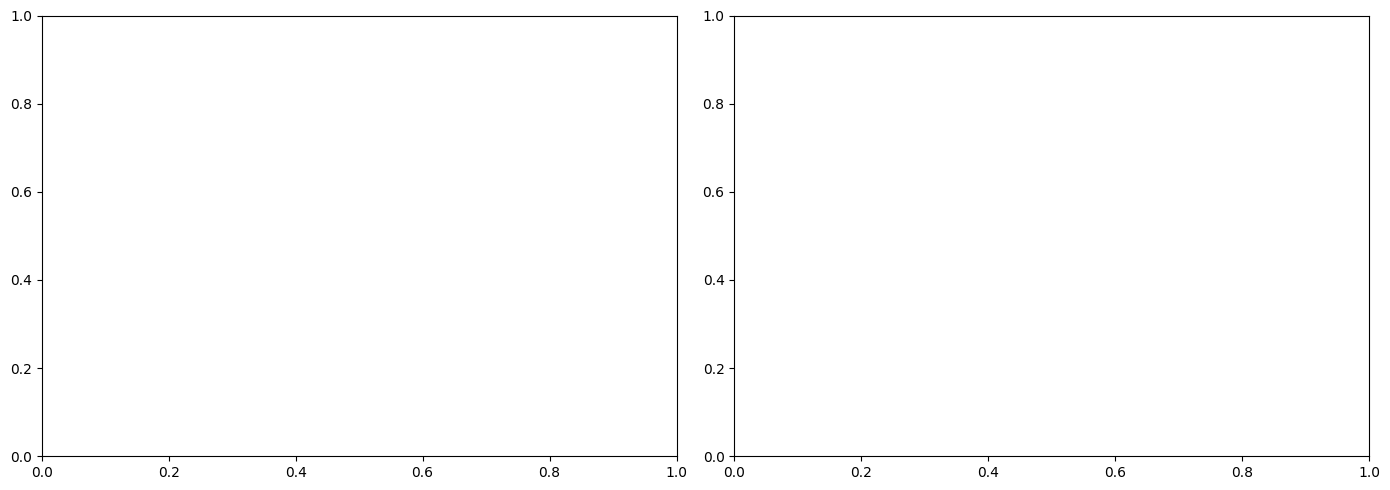

In [20]:
# ── Plot: Distinct Elements — Balanced vs Unbalanced (vary N) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

de_bal = bal_runs[bal_runs['circuit_type'] == 'Distinct Elements'].sort_values('n_clients')

if len(de_bal) > 0:
    x = de_bal['n_clients'].values
    axes[0].plot(x, de_bal['avg_comp_ms'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[0].plot(x, de_bal['max_comp_ms'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[0].plot(x, de_bal['unbal_comp_ms'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[0].set_xlabel('Number of Users (N)', fontsize=12)
    axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
    axes[0].set_title('Distinct Elements (k=4) — Computation', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, de_bal['avg_comm_KB'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='Balanced (avg client)')
    axes[1].plot(x, de_bal['max_comm_KB'], 's--', color='#2196F3', linewidth=1.5, markersize=6, alpha=0.6, label='Balanced (worst client)')
    axes[1].plot(x, de_bal['unbal_comm_KB'], 'D-', color='#F44336', linewidth=2, markersize=8, label='Unbalanced (client 0)')
    axes[1].set_xlabel('Number of Users (N)', fontsize=12)
    axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
    axes[1].set_title('Distinct Elements (k=4) — Communication', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── Plot: Distinct Elements — Speedup vs N ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(de_bal) > 0:
    x = de_bal['n_clients'].values
    axes[0].plot(x, de_bal['comp_speedup'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Users (N)')
    axes[0].set_ylabel('Computation Speedup (×)')
    axes[0].set_title('Distinct Elements — Computation Speedup (Unbal / Bal avg)')
    axes[0].set_xticks(x)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, de_bal['comm_speedup'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Users (N)')
    axes[1].set_ylabel('Communication Savings (×)')
    axes[1].set_title('Distinct Elements — Communication Savings (Unbal / Bal avg)')
    axes[1].set_xticks(x)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── Plot: Distinct Elements — Per-client breakdown (N=16) ────────────────
exp_name = [e for e in df['experiment'].unique() if 'distinct_N16_bal' in e]
if exp_name:
    breakdown = df[df['experiment'] == exp_name[0]].sort_values('client_id')
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = breakdown['client_id'].values
    w = 0.5

    axes[0].bar(x, breakdown['garble_time_us']/1000, w, label='Garble', color='#2196F3')
    axes[0].bar(x, breakdown['ot_are_time_us']/1000, w, bottom=breakdown['garble_time_us']/1000, label='OT-ARE', color='#FF9800')
    axes[0].bar(x, breakdown['boundary_time_us']/1000, w, bottom=(breakdown['garble_time_us']+breakdown['ot_are_time_us'])/1000, label='Boundary', color='#4CAF50')
    axes[0].set_xlabel('Client ID')
    axes[0].set_ylabel('Time (ms)')
    axes[0].set_title('Distinct Elements (N=16, k=4) — Per-client Computation')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].bar(x, breakdown['garbled_table_bytes']/1024, w, label='Garbled tables', color='#2196F3')
    axes[1].bar(x, breakdown['ot_are_bytes']/1024, w, bottom=breakdown['garbled_table_bytes']/1024, label='OT-ARE', color='#FF9800')
    axes[1].bar(x, breakdown['boundary_bytes']/1024, w, bottom=(breakdown['garbled_table_bytes']+breakdown['ot_are_bytes'])/1024, label='Boundary', color='#4CAF50')
    axes[1].set_xlabel('Client ID')
    axes[1].set_ylabel('Communication (KB)')
    axes[1].set_title('Distinct Elements (N=16, k=4) — Per-client Communication')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


## Distinct Elements — Bitonic vs Histogram
Compare the two realizations of the distinct-elements circuit across N.

In [ ]:
# ── Distinct Elements: Bitonic vs Histogram (balanced avg, vary N) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

de_bit  = bal_runs[bal_runs['circuit_type'] == 'Distinct Elements'].sort_values('n_clients')
de_hist = bal_runs[bal_runs['circuit_type'] == 'Distinct Elements (Histogram)'].sort_values('n_clients')

if len(de_bit) > 0:
    xb = de_bit['n_clients'].values
    axes[0].plot(xb, de_bit['avg_comp_ms'], 'o-',  color='#2196F3', linewidth=2, markersize=8, label='Bitonic (avg client)')
    axes[0].plot(xb, de_bit['max_comp_ms'], 's--', color='#2196F3', linewidth=1.2, markersize=6, alpha=0.55, label='Bitonic (worst client)')
    axes[1].plot(xb, de_bit['avg_comm_KB'], 'o-',  color='#2196F3', linewidth=2, markersize=8, label='Bitonic (avg client)')
    axes[1].plot(xb, de_bit['max_comm_KB'], 's--', color='#2196F3', linewidth=1.2, markersize=6, alpha=0.55, label='Bitonic (worst client)')

if len(de_hist) > 0:
    xh = de_hist['n_clients'].values
    axes[0].plot(xh, de_hist['avg_comp_ms'], 'o-',  color='#E91E63', linewidth=2, markersize=8, label='Histogram (avg client)')
    axes[0].plot(xh, de_hist['max_comp_ms'], 's--', color='#E91E63', linewidth=1.2, markersize=6, alpha=0.55, label='Histogram (worst client)')
    axes[1].plot(xh, de_hist['avg_comm_KB'], 'o-',  color='#E91E63', linewidth=2, markersize=8, label='Histogram (avg client)')
    axes[1].plot(xh, de_hist['max_comm_KB'], 's--', color='#E91E63', linewidth=1.2, markersize=6, alpha=0.55, label='Histogram (worst client)')

axes[0].set_xlabel('Number of Users (N)', fontsize=12)
axes[0].set_ylabel('Per-client Computation (ms)', fontsize=12)
axes[0].set_title('Distinct Elements (k=4) — Bitonic vs Histogram: Computation', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Number of Users (N)', fontsize=12)
axes[1].set_ylabel('Per-client Communication (KB)', fontsize=12)
axes[1].set_title('Distinct Elements (k=4) — Bitonic vs Histogram: Communication', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if len(de_bit) > 0:
    axes[0].set_xticks(de_bit['n_clients'].values)
    axes[1].set_xticks(de_bit['n_clients'].values)

plt.tight_layout()
plt.show()


In [ ]:
# ── Distinct Elements: Bitonic / Histogram ratio (balanced avg) ─────
if len(de_bit) > 0 and len(de_hist) > 0:
    merged = de_bit[['n_clients', 'avg_comp_ms', 'avg_comm_KB']].merge(
        de_hist[['n_clients', 'avg_comp_ms', 'avg_comm_KB']],
        on='n_clients', suffixes=('_bit', '_hist')
    ).sort_values('n_clients')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = merged['n_clients'].values
    axes[0].plot(x, merged['avg_comp_ms_bit'] / merged['avg_comp_ms_hist'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[0].set_xlabel('Number of Users (N)')
    axes[0].set_ylabel('Computation speedup (Bitonic / Histogram)')
    axes[0].set_title('Distinct Elements — Computation: Histogram vs Bitonic')
    axes[0].set_xticks(x)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, merged['avg_comm_KB_bit'] / merged['avg_comm_KB_hist'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Break-even')
    axes[1].set_xlabel('Number of Users (N)')
    axes[1].set_ylabel('Communication savings (Bitonic / Histogram)')
    axes[1].set_title('Distinct Elements — Communication: Histogram vs Bitonic')
    axes[1].set_xticks(x)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('Distinct Elements — Bitonic vs Histogram (balanced, avg client):')
    for _, row in merged.iterrows():
        print(f"  N={int(row['n_clients']):2d}  bitonic={row['avg_comp_ms_bit']:7.1f} ms / {row['avg_comm_KB_bit']:7.1f} KB    histogram={row['avg_comp_ms_hist']:7.1f} ms / {row['avg_comm_KB_hist']:7.1f} KB    comp×={row['avg_comp_ms_bit']/row['avg_comp_ms_hist']:.2f}  comm×={row['avg_comm_KB_bit']/row['avg_comm_KB_hist']:.2f}")
